Load in data

In [2]:
from pathlib import Path
import os
import subprocess
import sys

from google.colab import drive

drive.mount("/content/drive")

repo = Path("/content/facial-visual-profile")
if not repo.exists():
    subprocess.run(
        [
            "git", "clone",
            "https://github.com/DeweyYip/facial-visual-profile.git",
            str(repo),
        ],
        check=True,
    )

os.chdir(repo)
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

data_source = Path("/content/drive/MyDrive/FacialVisualProfile/data")
required = (
    "img_align_celeba.zip",
    "list_attr_celeba.txt",
    "list_landmarks_align_celeba.txt",
    "list_eval_partition.txt",
)

print(
    "Git commit:",
    subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"], text=True
    ).strip(),
)
for name in required:
    path = data_source / name
    print(f"{name}: {'FOUND' if path.is_file() else 'MISSING'}")

Mounted at /content/drive
Git commit: 43e51ca
img_align_celeba.zip: FOUND
list_attr_celeba.txt: FOUND
list_landmarks_align_celeba.txt: FOUND
list_eval_partition.txt: FOUND


unzip images

In [4]:
from pathlib import Path
import shutil
import subprocess
import time

repo = Path("/content/facial-visual-profile")
source = Path("/content/drive/MyDrive/FacialVisualProfile/data")
raw = repo / "data/raw"
raw.mkdir(parents=True, exist_ok=True)

required = (
    "img_align_celeba.zip",
    "list_attr_celeba.txt",
    "list_landmarks_align_celeba.txt",
    "list_eval_partition.txt",
)

started = time.perf_counter()

for name in required:
    src = source / name
    dst = raw / name
    assert src.is_file(), f"Missing Drive file: {src}"

    if not dst.is_file() or dst.stat().st_size != src.stat().st_size:
        print(f"Copying: {name}", flush=True)
        shutil.copy2(src, dst)
    else:
        print(f"Already copied: {name}", flush=True)

image_dir = raw / "img_align_celeba"
count = sum(1 for _ in image_dir.glob("*.jpg"))

if count != 202599:
    print("Extracting images...", flush=True)
    subprocess.run(
        ["unzip", "-oq", str(raw / "img_align_celeba.zip"), "-d", str(raw)],
        check=True,
    )
    count = sum(1 for _ in image_dir.glob("*.jpg"))

assert count == 202599, f"Expected 202599 images, found {count}"
print("Images ready:", count)
print(f"Preparation time: {(time.perf_counter() - started) / 60:.1f} minutes")

Copying: img_align_celeba.zip
Copying: list_attr_celeba.txt
Copying: list_landmarks_align_celeba.txt
Copying: list_eval_partition.txt
Extracting images...
Images ready: 202599
Preparation time: 1.0 minutes


Check the data status

In [5]:
from pathlib import Path
from importlib import metadata
import sys
import torch

repo = Path("/content/facial-visual-profile")

print("Python:", sys.version.split()[0])
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

for name in ("torch", "torchvision", "scikit-learn"):
    try:
        print(f"{name}: {metadata.version(name)}")
    except metadata.PackageNotFoundError:
        print(f"{name}: not installed")

checks = {
    "Repository": repo,
    "Model": repo / "models/resnet18.py",
    "Dataset": repo / "datasets/celeba.py",
    "First image": repo / "data/raw/img_align_celeba/000001.jpg",
    "Attributes": repo / "data/raw/list_attr_celeba.txt",
    "Landmarks": repo / "data/raw/list_landmarks_align_celeba.txt",
    "Partitions": repo / "data/raw/list_eval_partition.txt",
    "Google Drive": Path("/content/drive/MyDrive"),
}

for label, path in checks.items():
    print(f"{label}: {'FOUND' if path.exists() else 'MISSING'}")

Python: 3.13.15
CUDA available: True
GPU: Tesla T4
torch: 2.11.0+cu128
torchvision: 0.26.0+cu128
scikit-learn: 1.6.1
Repository: FOUND
Model: FOUND
Dataset: FOUND
First image: FOUND
Attributes: FOUND
Landmarks: FOUND
Partitions: FOUND
Google Drive: FOUND


Check the latest submitted files just so we don't submit twice

In [6]:
from pathlib import Path
import subprocess

repo = Path("/content/facial-visual-profile")

print(
    subprocess.check_output(
        ["git", "log", "-3", "--oneline"],
        cwd=repo,
        text=True,
    )
)

for folder_name in ("training", "evaluation", "scripts", "models"):
    folder = repo / folder_name
    print(f"\n{folder_name}/")
    if folder.is_dir():
        for path in sorted(folder.glob("*.py")):
            print(" ", path.name)
    else:
        print("  MISSING")

43e51ca Updates on Day 4 and Day 5 code
09a8b99 Document MTCNN cache and landmark quality assessment
23135eb Add MTCNN detector and resumable landmark cache


training/
  __init__.py

evaluation/
  __init__.py

scripts/
  cache_mtcnn.py
  inspect_celeba.py
  overfit_resnet18.py

models/
  __init__.py
  resnet18.py


In [7]:
# Create reusable validation metrics for 24 independent binary attributes.
# F1 uses a fixed probability threshold of 0.5 for this experiment.
# mAP is the mean of per-attribute average precision scores.

from pathlib import Path

path = Path("/content/facial-visual-profile/evaluation/attributes.py")
code = '''"""Validation metrics for multi-label facial attributes."""

import numpy as np
from sklearn.metrics import average_precision_score, f1_score


def evaluate_attributes(logits, targets, threshold=0.5):
    """Compute macro F1 and mAP from all validation samples.

    Args:
        logits: Array with shape (samples, attributes), before sigmoid.
        targets: Binary array with the same shape.
        threshold: Probability threshold used for F1 only.

    Returns:
        A dictionary containing aggregate and per-attribute metrics.
    """
    logits = np.asarray(logits, dtype=np.float64)
    targets = np.asarray(targets)

    if logits.ndim != 2 or logits.shape != targets.shape:
        raise ValueError("Logits and targets must have the same 2D shape")
    if logits.shape[0] == 0:
        raise ValueError("At least one sample is required")
    if not np.isfinite(logits).all():
        raise ValueError("Logits contain non-finite values")
    if not np.isin(targets, [0, 1]).all():
        raise ValueError("Targets must be binary")
    if not 0.0 < threshold < 1.0:
        raise ValueError("Threshold must be between zero and one")

    # The stable sigmoid form avoids overflow for large logits.
    probabilities = np.empty_like(logits)
    positive = logits >= 0
    probabilities[positive] = 1.0 / (
        1.0 + np.exp(-logits[positive])
    )
    exp_logits = np.exp(logits[~positive])
    probabilities[~positive] = exp_logits / (1.0 + exp_logits)

    predictions = probabilities >= threshold
    per_attribute_f1 = f1_score(
        targets,
        predictions,
        average=None,
        zero_division=0,
    )

    per_attribute_ap = []
    for index in range(targets.shape[1]):
        labels = targets[:, index]
        if np.unique(labels).size < 2:
            raise ValueError(
                f"Attribute {index} has only one class in validation"
            )
        per_attribute_ap.append(
            float(average_precision_score(
                labels, probabilities[:, index]
            ))
        )

    return {
        "threshold": float(threshold),
        "macro_f1": float(np.mean(per_attribute_f1)),
        "map": float(np.mean(per_attribute_ap)),
        "per_attribute_f1": per_attribute_f1.tolist(),
        "per_attribute_ap": per_attribute_ap,
        "positive_counts": targets.sum(axis=0).astype(int).tolist(),
    }
'''

path.write_text(code, encoding="utf-8")
print("Created:", path)

import sys
sys.path.insert(0, "/content/facial-visual-profile")

import numpy as np
from evaluation.attributes import evaluate_attributes

example_logits = np.array([
    [2.0, -2.0],
    [-2.0, 2.0],
    [1.0, -1.0],
    [-1.0, 1.0],
])
example_targets = np.array([
    [1, 0],
    [0, 1],
    [1, 0],
    [0, 1],
])

example = evaluate_attributes(example_logits, example_targets)
assert example["macro_f1"] == 1.0
assert example["map"] == 1.0
print("Metric check passed:", {
    "macro_f1": example["macro_f1"],
    "map": example["map"],
})

Created: /content/facial-visual-profile/evaluation/attributes.py
Metric check passed: {'macro_f1': 1.0, 'map': 1.0}


Prepare what we need for training

In [8]:
# Prepare the seed-0 ResNet18 experiment without starting training.
# Load the official train/validation splits and verify label consistency.
# Initialize fresh ImageNet weights; do not load the Day 4 checkpoint.

import os
import random
import subprocess
from pathlib import Path

import numpy as np
import torch
from torch import nn

repo = Path("/content/facial-visual-profile")
os.chdir(repo)

from datasets.celeba import CelebAAttributes
from models.resnet18 import ResNet18Attributes

assert torch.cuda.is_available(), "A CUDA GPU is required."
assert Path("/content/drive/MyDrive").is_dir(), "Mount Google Drive first."

config = {
    "seed": 0,
    "epochs": 10,
    "batch_size": 64,
    "num_workers": 2,
    "optimizer": "Adam",
    "learning_rate": 0.0001,
    "weight_decay": 0.0,
    "precision": "FP32",
    "initial_weights": "ResNet18_Weights.IMAGENET1K_V1",
    "augmentation": "None; use existing shared preprocessing",
    "f1_threshold": 0.5,
    "selection_metric": "validation_mAP",
}

random.seed(config["seed"])
np.random.seed(config["seed"])
torch.manual_seed(config["seed"])
torch.cuda.manual_seed_all(config["seed"])

# Reduce run-to-run variation; exact reproducibility across environments
# is not guaranteed.
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

device = torch.device("cuda")

train_dataset = CelebAAttributes("train")
valid_dataset = CelebAAttributes("valid")

assert len(train_dataset) == 162770
assert len(valid_dataset) == 19867
assert train_dataset.attribute_names == valid_dataset.attribute_names
assert len(train_dataset.attribute_names) == 24
assert set(train_dataset.names).isdisjoint(valid_dataset.names)

# AP evaluation requires positive and negative examples for each attribute.
valid_targets = torch.stack([
    valid_dataset.targets[name] for name in valid_dataset.names
])
positive_counts = valid_targets.sum(dim=0)
assert torch.all(positive_counts > 0)
assert torch.all(positive_counts < len(valid_dataset))
del valid_targets

model = ResNet18Attributes(
    num_attributes=len(train_dataset.attribute_names),
    pretrained=True,
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"],
)
criterion = nn.BCEWithLogitsLoss()

config["attribute_names"] = list(train_dataset.attribute_names)
config["git_commit"] = subprocess.check_output(
    ["git", "rev-parse", "HEAD"], text=True
).strip()

print("GPU:", torch.cuda.get_device_name(0))
print("Seed:", config["seed"])
print("Training images:", len(train_dataset))
print("Validation images:", len(valid_dataset))
print("Attributes:", len(config["attribute_names"]))
print("Epochs:", config["epochs"])
print("Batch size:", config["batch_size"])
print("Learning rate:", config["learning_rate"])
print("Setup passed. Training has not started.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


GPU: Tesla T4
Seed: 0
Training images: 162770
Validation images: 19867
Attributes: 24
Epochs: 10
Batch size: 64
Learning rate: 0.0001
Setup passed. Training has not started.


Official training for 10 epochs

In [ ]:
# Train ResNet18 for seed 0 and evaluate the full validation set each epoch.
# Save one checkpoint per completed epoch to Google Drive.
# On rerun, resume from the latest completed epoch in the same run directory.

import hashlib
import json
import platform
import random
import time
from importlib import metadata
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from evaluation.attributes import evaluate_attributes

run_dir = Path(
    "/content/drive/MyDrive/FacialVisualProfile/runs/r18_seed0"
)
run_dir.mkdir(parents=True, exist_ok=True)

# Record the exact source files and environment used by this experiment.
source_names = (
    "models/resnet18.py",
    "datasets/celeba.py",
    "datasets/preprocessing.py",
    "configs/attributes.yaml",
    "evaluation/attributes.py",
)
sources = {
    name: (repo / name).read_text(encoding="utf-8")
    for name in source_names
}
config["source_sha256"] = {
    name: hashlib.sha256(text.encode("utf-8")).hexdigest()
    for name, text in sources.items()
}
config["environment"] = {
    "python": platform.python_version(),
    **{
        name: metadata.version(name)
        for name in (
            "torch", "torchvision", "numpy",
            "Pillow", "scikit-learn",
        )
    },
}
config["epoch_seed_rule"] = "seed + epoch; epochs start at 1"
config["cudnn_deterministic"] = True
config["cudnn_benchmark"] = False


def save_json(value, path):
    temporary = path.with_name(path.name + ".tmp")
    temporary.write_text(
        json.dumps(value, indent=2, allow_nan=False) + "\n",
        encoding="utf-8",
    )
    temporary.replace(path)


config_path = run_dir / "config.json"
if config_path.exists():
    saved_config = json.loads(config_path.read_text(encoding="utf-8"))
    if saved_config != config:
        raise ValueError(
            "Run configuration changed. Restore the original configuration "
            "or use a new run directory."
        )
else:
    save_json(config, config_path)

for name, text in sources.items():
    destination = run_dir / "source" / name
    destination.parent.mkdir(parents=True, exist_ok=True)
    destination.write_text(text, encoding="utf-8")


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def make_loader(dataset, shuffle, seed):
    return DataLoader(
        dataset,
        batch_size=config["batch_size"],
        shuffle=shuffle,
        generator=torch.Generator().manual_seed(seed),
        num_workers=config["num_workers"],
        worker_init_fn=seed_worker,
        pin_memory=True,
        drop_last=False,
    )


# Restore a checkpoint created by this experiment, if one exists.
checkpoints = sorted(run_dir.glob("epoch_[0-9][0-9].pt"))
history = []
start_epoch = 1

if checkpoints:
    latest = checkpoints[-1]
    checkpoint = torch.load(
        latest, map_location="cpu", weights_only=True
    )
    if checkpoint["config"] != config:
        raise ValueError("Checkpoint configuration mismatch")

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    history = checkpoint["history"]
    start_epoch = checkpoint["epoch"] + 1
    del checkpoint

    print("Resumed from:", latest.name, flush=True)

print("Run directory:", run_dir, flush=True)
print("Next epoch:", start_epoch, flush=True)

for epoch in range(start_epoch, config["epochs"] + 1):
    # Reseeding at epoch boundaries makes interrupted-epoch replay consistent.
    epoch_seed = config["seed"] + epoch
    random.seed(epoch_seed)
    np.random.seed(epoch_seed)
    torch.manual_seed(epoch_seed)
    torch.cuda.manual_seed_all(epoch_seed)

    train_loader = make_loader(train_dataset, True, epoch_seed)
    valid_loader = make_loader(valid_dataset, False, epoch_seed)

    torch.cuda.synchronize()
    started = time.perf_counter()

    model.train()
    train_loss_sum = 0.0
    train_count = 0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch}/{config['epochs']} train",
    )
    for images, targets, _, _ in progress:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, targets)

        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite training loss")

        loss.backward()
        optimizer.step()

        count = images.size(0)
        train_loss_sum += loss.item() * count
        train_count += count

        if train_count % (config["batch_size"] * 50) == 0:
            progress.set_postfix(
                loss=f"{train_loss_sum / train_count:.4f}"
            )

    assert train_count == len(train_dataset)

    # Compute metrics once over the entire validation set, not per batch.
    model.eval()
    valid_loss_sum = 0.0
    valid_count = 0
    logits_parts = []
    target_parts = []

    with torch.inference_mode():
        for images, targets, _, _ in tqdm(
            valid_loader,
            desc=f"Epoch {epoch}/{config['epochs']} valid",
        ):
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, targets)
            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite validation loss")

            count = images.size(0)
            valid_loss_sum += loss.item() * count
            valid_count += count
            logits_parts.append(logits.cpu())
            target_parts.append(targets.cpu())

    assert valid_count == len(valid_dataset)

    metrics = evaluate_attributes(
        torch.cat(logits_parts).numpy(),
        torch.cat(target_parts).numpy(),
        threshold=config["f1_threshold"],
    )
    del logits_parts, target_parts

    torch.cuda.synchronize()
    record = {
        "epoch": epoch,
        "train_loss": train_loss_sum / train_count,
        "valid_loss": valid_loss_sum / valid_count,
        "validation": metrics,
        "seconds_excluding_save": time.perf_counter() - started,
    }
    history.append(record)

    checkpoint_path = run_dir / f"epoch_{epoch:02d}.pt"
    temporary = checkpoint_path.with_name(
        checkpoint_path.name + ".tmp"
    )
    torch.save(
        {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "config": config,
            "history": history,
        },
        temporary,
    )
    temporary.replace(checkpoint_path)

    best_record = max(
        history, key=lambda row: row["validation"]["map"]
    )
    save_json(history, run_dir / "history.json")
    save_json(
        {
            "epoch": best_record["epoch"],
            "checkpoint": f"epoch_{best_record['epoch']:02d}.pt",
            "validation_map": best_record["validation"]["map"],
            "validation_macro_f1": best_record["validation"]["macro_f1"],
        },
        run_dir / "best.json",
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {record['train_loss']:.4f} | "
        f"valid loss {record['valid_loss']:.4f} | "
        f"F1 {metrics['macro_f1']:.4f} | "
        f"mAP {metrics['map']:.4f}",
        flush=True,
    )
    print("Saved:", checkpoint_path.name, flush=True)

# Rebuild summaries from checkpoint history if an earlier save was interrupted.
if history:
    best_record = max(
        history, key=lambda row: row["validation"]["map"]
    )
    best_summary = {
        "epoch": best_record["epoch"],
        "checkpoint": f"epoch_{best_record['epoch']:02d}.pt",
        "validation_map": best_record["validation"]["map"],
        "validation_macro_f1": best_record["validation"]["macro_f1"],
    }
    save_json(history, run_dir / "history.json")
    save_json(best_summary, run_dir / "best.json")
    print("Training complete. Best validation result:", best_summary)

Run directory: /content/drive/MyDrive/FacialVisualProfile/runs/r18_seed0
Next epoch: 1


Epoch 1/10 train:   0%|          | 0/2544 [00:00<?, ?it/s]

Epoch 1/10 valid:   0%|          | 0/311 [00:00<?, ?it/s]

Epoch 01 | train loss 0.2141 | valid loss 0.1957 | F1 0.7292 | mAP 0.8138
Saved: epoch_01.pt


Epoch 2/10 train:   0%|          | 0/2544 [00:00<?, ?it/s]

...

Epoch 08 | train loss 0.0702 | valid loss 0.2930 | F1 0.7193 | mAP 0.7804
Saved: epoch_08.pt


Epoch 9/10 train:   0%|          | 0/2544 [00:00<?, ?it/s]

Epoch 9/10 valid:   0%|          | 0/311 [00:00<?, ?it/s]

Epoch 09 | train loss 0.0529 | valid loss 0.3329 | F1 0.7199 | mAP 0.7748
Saved: epoch_09.pt


Epoch 10/10 train:   0%|          | 0/2544 [00:00<?, ?it/s]

10 epochs have been finished

In [1]:
# Mount Google Drive and inspect saved checkpoints.
# Load the latest checkpoint on CPU to verify that it is readable.
# This cell does not train the model or modify saved files.

from pathlib import Path
import torch
from google.colab import drive

drive.mount("/content/drive")

run_dir = Path(
    "/content/drive/MyDrive/FacialVisualProfile/runs/r18_seed0"
)
assert run_dir.is_dir(), f"Missing run directory: {run_dir}"

checkpoints = sorted(run_dir.glob("epoch_[0-9][0-9].pt"))
assert checkpoints, "No completed checkpoints found. Stop here."

for path in checkpoints:
    print(f"{path.name}: {path.stat().st_size / 1024**2:.2f} MiB")

latest = checkpoints[-1]
checkpoint = torch.load(
    latest, map_location="cpu", weights_only=True
)

print("\nLatest readable checkpoint:", latest.name)
print("Completed epoch:", checkpoint["epoch"])
print("Next epoch:", checkpoint["epoch"] + 1)
print("Planned epochs:", checkpoint["config"]["epochs"])
print("Original git commit:", checkpoint["config"]["git_commit"])

best = max(
    checkpoint["history"],
    key=lambda row: row["validation"]["map"],
)
print("Best completed epoch:", best["epoch"])
print(f"Best validation mAP: {best['validation']['map']:.4f}")

del checkpoint

Mounted at /content/drive
epoch_01.pt: 128.18 MiB
epoch_02.pt: 128.18 MiB
epoch_03.pt: 128.18 MiB
epoch_04.pt: 128.18 MiB
epoch_05.pt: 128.18 MiB
epoch_06.pt: 128.18 MiB
epoch_07.pt: 128.18 MiB
epoch_08.pt: 128.18 MiB
epoch_09.pt: 128.18 MiB
epoch_10.pt: 128.18 MiB

Latest readable checkpoint: epoch_10.pt
Completed epoch: 10
Next epoch: 11
Planned epochs: 10
Original git commit: 43e51ca99bf98743ba2d7c4e2481e2b7751e97f7
Best completed epoch: 3
Best validation mAP: 0.8177


Save the data

In [2]:
# Read all completed epoch metrics from the final checkpoint.
# Refresh the training history and best-checkpoint summary on Google Drive.
# This cell requires no GPU and performs no training.

import json
from pathlib import Path
import torch

run_dir = Path(
    "/content/drive/MyDrive/FacialVisualProfile/runs/r18_seed0"
)
checkpoint = torch.load(
    run_dir / "epoch_10.pt",
    map_location="cpu",
    weights_only=True,
)
history = checkpoint["history"]

assert checkpoint["epoch"] == 10
assert [row["epoch"] for row in history] == list(range(1, 11))

print("Epoch | Train loss | Valid loss | Macro F1 | mAP")
for row in history:
    metrics = row["validation"]
    print(
        f"{row['epoch']:5d} | "
        f"{row['train_loss']:.4f}     | "
        f"{row['valid_loss']:.4f}     | "
        f"{metrics['macro_f1']:.4f}   | "
        f"{metrics['map']:.4f}"
    )

best = max(history, key=lambda row: row["validation"]["map"])
summary = {
    "epoch": best["epoch"],
    "checkpoint": f"epoch_{best['epoch']:02d}.pt",
    "validation_map": best["validation"]["map"],
    "validation_macro_f1": best["validation"]["macro_f1"],
}

for name, value in (
    ("history.json", history),
    ("best.json", summary),
):
    path = run_dir / name
    temporary = path.with_name(path.name + ".tmp")
    temporary.write_text(
        json.dumps(value, indent=2, allow_nan=False) + "\n",
        encoding="utf-8",
    )
    temporary.replace(path)

print("\nSelected checkpoint:", summary["checkpoint"])
print("History and best-checkpoint summary saved.")
del checkpoint

Epoch | Train loss | Valid loss | Macro F1 | mAP
    1 | 0.2141     | 0.1957     | 0.7292   | 0.8138
    2 | 0.1867     | 0.1948     | 0.7415   | 0.8166
    3 | 0.1747     | 0.1907     | 0.7273   | 0.8177
    4 | 0.1606     | 0.1976     | 0.7405   | 0.8145
    5 | 0.1418     | 0.2051     | 0.7310   | 0.8052
    6 | 0.1185     | 0.2291     | 0.7315   | 0.7961
    7 | 0.0933     | 0.2610     | 0.7125   | 0.7854
    8 | 0.0702     | 0.2930     | 0.7193   | 0.7804
    9 | 0.0529     | 0.3329     | 0.7199   | 0.7748
   10 | 0.0416     | 0.3669     | 0.7166   | 0.7698

Selected checkpoint: epoch_03.pt
History and best-checkpoint summary saved.


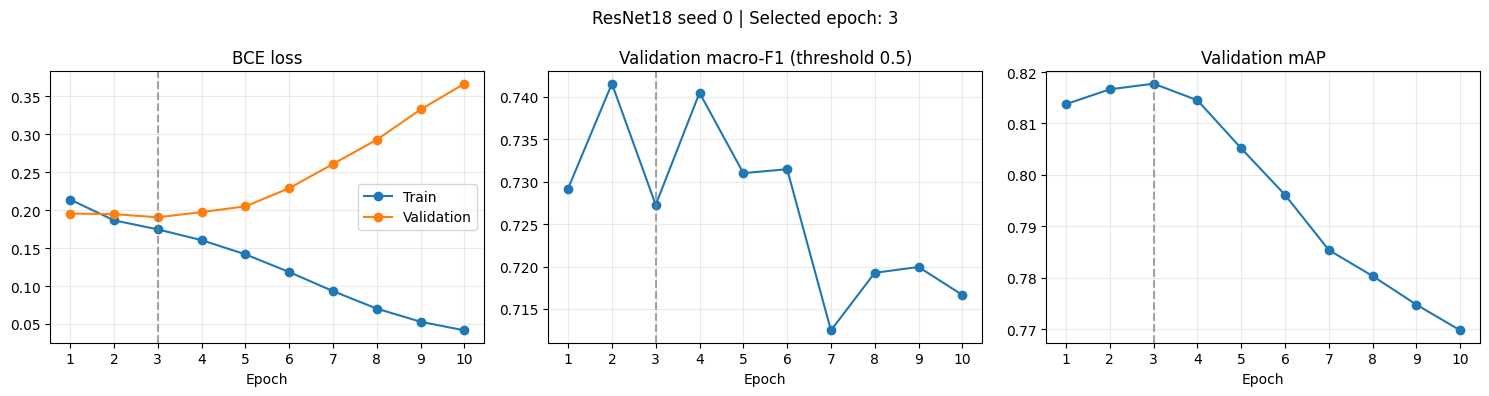

Saved: /content/drive/MyDrive/FacialVisualProfile/runs/r18_seed0/training_curves.png
Saved: /content/drive/MyDrive/FacialVisualProfile/runs/r18_seed0/epoch_metrics.csv


In [3]:
# Plot the completed training history and mark the selected checkpoint.
# Save the figure and an epoch-metrics CSV to Google Drive.
# This cell performs no model inference or training.

import csv
import json
from pathlib import Path
import matplotlib.pyplot as plt

run_dir = Path(
    "/content/drive/MyDrive/FacialVisualProfile/runs/r18_seed0"
)
history = json.loads(
    (run_dir / "history.json").read_text(encoding="utf-8")
)
best = max(history, key=lambda row: row["validation"]["map"])
epochs = [row["epoch"] for row in history]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(
    epochs, [r["train_loss"] for r in history],
    marker="o", label="Train",
)
axes[0].plot(
    epochs, [r["valid_loss"] for r in history],
    marker="o", label="Validation",
)
axes[0].set_title("BCE loss")
axes[0].legend()

axes[1].plot(
    epochs, [r["validation"]["macro_f1"] for r in history],
    marker="o",
)
axes[1].set_title("Validation macro-F1 (threshold 0.5)")

axes[2].plot(
    epochs, [r["validation"]["map"] for r in history],
    marker="o",
)
axes[2].set_title("Validation mAP")

for ax in axes:
    ax.axvline(
        best["epoch"], color="gray", linestyle="--", alpha=0.7
    )
    ax.set_xlabel("Epoch")
    ax.set_xticks(epochs)
    ax.grid(alpha=0.25)

fig.suptitle(
    f"ResNet18 seed 0 | Selected epoch: {best['epoch']}"
)
fig.tight_layout()
figure_path = run_dir / "training_curves.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

csv_path = run_dir / "epoch_metrics.csv"
with csv_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "epoch", "train_loss", "valid_loss",
        "validation_macro_f1", "validation_map",
    ])
    for row in history:
        writer.writerow([
            row["epoch"],
            row["train_loss"],
            row["valid_loss"],
            row["validation"]["macro_f1"],
            row["validation"]["map"],
        ])

print("Saved:", figure_path)
print("Saved:", csv_path)